# Computer Vision — Session 2: Pretrained Models & Transfer Learning
### ITI · Instructor: Ahmed Abdelsalam

Last time you trained a tiny CNN from scratch. Today you'll use models that were **already trained on millions of images** — and adapt them to your own task in minutes. This is how real CV projects are actually done.

**Today's map**
1. Why pretrained models?
2. Loading a pretrained model
3. Making a prediction (inference)
4. The model zoo (which model to pick)
5. Why preprocessing must match
6. Transfer learning — the big idea
7. A peek at detection & segmentation

> **Setup:** made for **Google Colab**. For the training part, switch to a GPU runtime: *Runtime → Change runtime type → GPU* (optional but faster).

## Setup — run this first

In [22]:
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data
print("torch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

torch: 2.11.0+cu128
GPU available: True


## 1. Why pretrained models?

Training a good image model from scratch needs:
- **Millions** of labelled images (e.g. **ImageNet** = 1.2M images, 1000 classes)
- **Days** of GPU time
- Lots of tuning

Almost nobody does this. Instead we **reuse** a model someone already trained. The key insight:

> A network trained on ImageNet has already learned to see **edges, textures, shapes, and parts** in its early layers. Those features are useful for *almost any* image task — not just the original 1000 classes.

So we download those learned features for free and build on top of them.

## 2. Loading a pretrained model

`torchvision` gives us famous models with their trained weights in one line. The modern API bundles the weights **together with** the exact preprocessing and the class names — very convenient.

In [23]:
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.DEFAULT          # the trained weights (downloads once)
model = models.resnet18(weights=weights)    # ResNet-18, ready to use
model.eval()                                # evaluation mode (important for inference)

print("Loaded ResNet-18")
print("It knows", len(weights.meta["categories"]), "classes")   # 1000 ImageNet classes
print("The first 5 are:", weights.meta["categories"][:])

Loaded ResNet-18
It knows 1000 classes
The first 5 are: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'gr

The `weights` object carries two things we'll need:

In [24]:
preprocess = weights.transforms()        # the EXACT preprocessing this model expects
categories = weights.meta["categories"]  # human-readable class names

print(preprocess)
print("\nExample classes:", categories[281], "/", categories[207])

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Example classes: tabby / golden retriever


## 3. Making a prediction (inference)

Three steps to classify an image:
1. **Preprocess** it (resize, normalize, to tensor) — using the model's own transforms.
2. **Forward pass** → the model outputs raw scores called **logits**.
3. **Softmax** turns logits into probabilities; **top-k** picks the most likely classes.

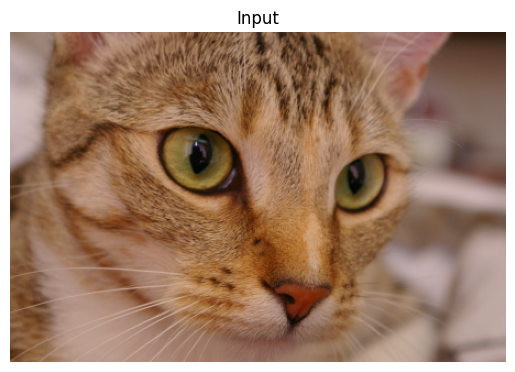

In [25]:
img = Image.fromarray(data.chelsea())   # a cat photo (ships with skimage)
plt.imshow(img)
plt.axis("off")
plt.title("Input")
plt.show()


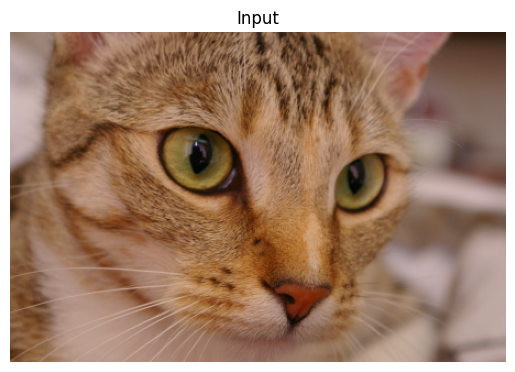

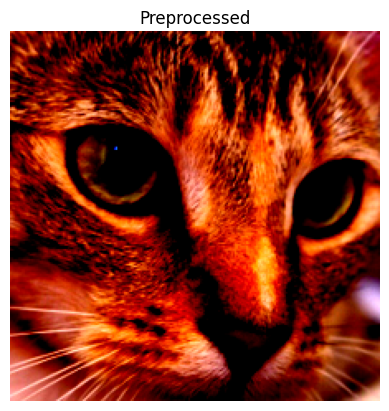

Top-5 predictions:
  Egyptian cat          39.1%
  tiger cat             38.6%
  tabby                 21.8%
  lynx                   0.5%
  Persian cat            0.0%


In [26]:
img = Image.fromarray(data.chelsea())   # a cat photo (ships with skimage)
plt.imshow(img)
plt.axis("off")
plt.title("Input")
plt.show()

# 1) preprocess -> add a batch dimension
x = preprocess(img).unsqueeze(0)        # shape (1, 3, 224, 224)
plt.imshow(x[0].permute(1, 2, 0))       # shape (3, 224, 224) -> (224, 224, 3)
plt.axis("off")
plt.title("Preprocessed")
plt.show()
# 2) forward pass
with torch.no_grad():
    logits = model(x)

# 3) probabilities + top 5
probs = torch.softmax(logits, dim=1)
top5 = torch.topk(probs, 5)

print("Top-5 predictions:")
for score, idx in zip(top5.values[0], top5.indices[0]):
    print(f"  {categories[idx]:20s} {score.item()*100:5.1f}%")

> No training, no dataset — just a download and three steps, and it correctly recognises the cat. That's the power of pretrained models.

🔵 **Your turn:** run the same three steps on a different sample image, `data.coffee()`. What are the top-3 predictions?

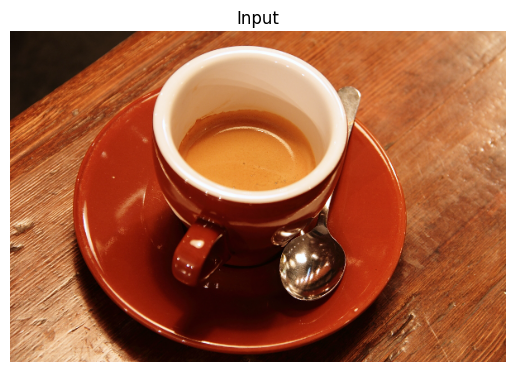

Top-5 predictions:
  espresso              85.2%
  chocolate sauce        4.0%
  consomme               3.9%
  soup bowl              2.5%
  cup                    2.0%
  coffee mug             1.2%
  eggnog                 0.1%
  mixing bowl            0.1%
  teapot                 0.1%
  tray                   0.1%


In [27]:
from logging import log
# Write your code here
coffee = Image.fromarray(data.coffee())
plt.imshow(coffee)
plt.axis("off")
plt.title("Input")
plt.show()

preprocess = weights.transforms()
coffee = preprocess(coffee).unsqueeze(0)
coffee_logits = model(coffee)
coffee_probs = torch.softmax(coffee_logits, dim=1)
coffee_top5 = torch.topk(coffee_probs, 10)

print("Top-5 predictions:")
for score, idx in zip(coffee_top5.values[0], coffee_top5.indices[0]):
    print(f"  {categories[idx]:20s} {score.item()*100:5.1f}%")

## 4. The model zoo — which one do I pick?

`torchvision` offers many pretrained models. You don't need to memorise them — just know the trade-off: **bigger = more accurate but slower**.

| Model | Size | Speed | Notes |
|-------|------|-------|-------|
| **MobileNet** | small | fast | phones, real-time, edge devices |
| **ResNet** (18/50) | medium | medium | the reliable default — great starting point |
| **EfficientNet** | medium | medium | strong accuracy for its size |
| **VGG** (16/19) | large | slow | older, simple, heavy — mostly for teaching |

**Rule of thumb:** start with **ResNet-18 or ResNet-50**. Move to MobileNet if you need speed, EfficientNet if you need more accuracy.

Loading any of them looks the same:

In [31]:
# Same pattern, different model — just don't run the big ones now unless you want the download
mobilenet = models.mobilenet_v3_small(weights="DEFAULT")
resnet50  = models.resnet50(weights="DEFAULT")
print("All loaded with the same one-line pattern.")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 129MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


All loaded with the same one-line pattern.


In [ ]:
W X IMAGE

## 5. Why preprocessing MUST match

A pretrained model was trained on images prepared a **specific** way: resized to 224×224, and normalized with specific mean/std values. If you feed it images prepared differently, it sees "wrong" numbers and gives nonsense.

This is the single most common mistake. Watch what happens with the wrong preprocessing:

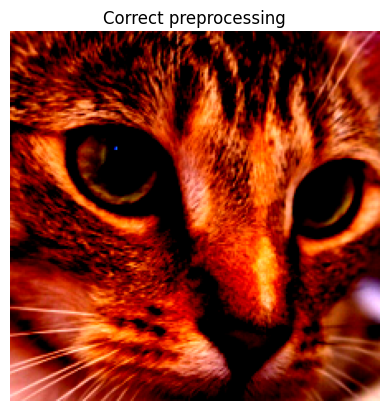

correct preprocessing -> ('Egyptian cat', 0.39144155383110046)


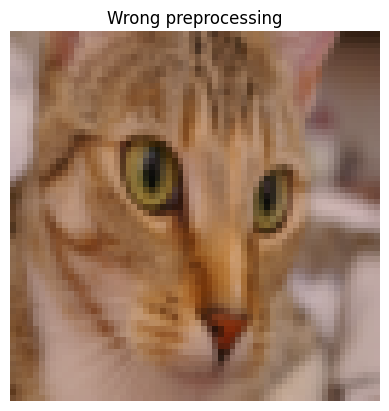

wrong   preprocessing -> ('trench coat', 0.5038968324661255)


In [34]:
from torchvision import transforms

def top1(x):
    with torch.no_grad():
        p = torch.softmax(model(x), dim=1)
    idx = p.argmax(dim=1).item()
    return categories[idx], p[0, idx].item()

# CORRECT: the model's own transforms
correct = weights.transforms()
plt.imshow(correct(img).permute(1, 2, 0).numpy()) # Fix: permute and convert to numpy
plt.axis("off")
plt.title("Correct preprocessing")
plt.show()
print("correct preprocessing ->", top1(correct(img).unsqueeze(0)))

# WRONG: tiny size, no normalization
wrong = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
plt.imshow(wrong(img).permute(1, 2, 0).numpy()) # Fix: permute and convert to numpy
plt.axis("off")
plt.title("Wrong preprocessing")
plt.show()
print("wrong   preprocessing ->", top1(wrong(img).unsqueeze(0)))

> Same cat, same model — but the wrong preprocessing makes it confidently wrong. **Always use `weights.transforms()`** (or match the documented mean/std). You'll debug exactly this in the lab.

## 6. Transfer learning — the big idea

What if your task isn't one of ImageNet's 1000 classes? Say you need to tell **ants from bees**, or classify medical scans. You **transfer** the pretrained model's knowledge to your task.

Two flavours:

| Approach | What you do | When |
|----------|-------------|------|
| **Feature extraction** | **Freeze** the pretrained layers, replace only the final classifier, train just that | small dataset (most common) |
| **Fine-tuning** | Also let some pretrained layers keep learning (small learning rate) | larger dataset, task quite different |

Today we do **feature extraction** — the simplest and most useful. Three steps:

In [35]:
# Step 1: load the pretrained model
tl_model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Step 2: FREEZE all the pretrained layers (they won't be trained)
for param in tl_model.parameters():
    param.requires_grad = False

# Step 3: replace the final layer with a NEW one for OUR classes (e.g. 2 classes)
num_features = tl_model.fc.in_features          # what the old classifier received
tl_model.fc = nn.Linear(num_features, 2)        # new, trainable, 2-class head

# Only the new head will train:
trainable = [name for name, p in tl_model.named_parameters() if p.requires_grad]
print("Trainable parts:", trainable)

Trainable parts: ['fc.weight', 'fc.bias']


## 4. Preparing your images with the model's transforms

First, let's download the dataset. This dataset contains images of ants and bees, perfectly suited for our transfer learning example.

In [37]:
# Download the dataset
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip -O hymenoptera_data.zip

--2026-07-16 18:33:38--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 143.204.160.77, 143.204.160.115, 143.204.160.84, ...
Connecting to download.pytorch.org (download.pytorch.org)|143.204.160.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘hymenoptera_data.zip’

hymenoptera_data.zi 100%[===================>]  45.10M   157MB/s    in 0.3s    

2026-07-16 18:33:38 (157 MB/s) - ‘hymenoptera_data.zip’ saved [47286322/47286322]



Now, we need to extract the downloaded dataset. We'll extract it to the `data` directory, matching the `data_dir` variable previously defined.

In [38]:
# Extract the dataset
import zipfile
import os

with zipfile.ZipFile('hymenoptera_data.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

print(f"Dataset extracted to: {os.path.abspath('data')}")
print(f"Contents of data directory: {os.listdir('data')}")
print(f"Contents of data/hymenoptera_data: {os.listdir('data/hymenoptera_data')}")

Dataset extracted to: /content/data
Contents of data directory: ['hymenoptera_data']
Contents of data/hymenoptera_data: ['train', 'val']


With the dataset downloaded and extracted, you can now run the cells to create the `ImageFolder` datasets and `DataLoaders` (cells `7905dff8` and `ec1b6c51`).

In [40]:
from torchvision import datasets
from torch.utils.data import DataLoader

# Assuming your dataset is structured like:
# data/
#   train/
#     ant/
#       xxx.png
#       yyy.png
#     bee/
#       zzz.png
#   val/
#     ant/
#       aaa.png
#       bbb.png

# Fix: Update data_dir to point to the correct subdirectory after extraction
data_dir = 'data/hymenoptera_data'
image_transforms = weights.transforms()

# Create training and validation datasets
train_dataset = datasets.ImageFolder(f'{data_dir}/train', image_transforms)
val_dataset = datasets.ImageFolder(f'{data_dir}/val', image_transforms)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training dataset size: 244
Validation dataset size: 153
Classes: ['ants', 'bees']


In [41]:
batch_size = 32 # You can adjust this

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 8
Number of validation batches: 5


Note: You would need to create the `data/train/ant`, `data/train/bee`, etc., directories and populate them with images for this code to run successfully.

> Everything except the new `fc` layer is frozen. We keep all the powerful learned features and only teach a small new decision layer. This trains fast and works even with a few hundred images — you'll see it hit high accuracy in the lab in **one epoch**.

In [42]:
import torch.optim as optim
import time
import copy

# 5. Train only the new head on your dataset (Feature Extraction)

# Define device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
tl_model = tl_model.to(device)

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized, as
# opposed to before where all parameters were optimized.
optimizer = optim.SGD(tl_model.fc.parameters(), lr=0.001, momentum=0.9)

# Training function
def train_model(model, criterion, optimizer, num_epochs=3):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

# Start training
print("Starting training...")
tl_model = train_model(tl_model, criterion, optimizer, num_epochs=10)
print("Training finished.")

Starting training...
Epoch 0/9
----------
train Loss: 0.6635 Acc: 0.6066
val Loss: 0.5358 Acc: 0.7386

Epoch 1/9
----------
train Loss: 0.4951 Acc: 0.7910
val Loss: 0.4041 Acc: 0.8889

Epoch 2/9
----------
train Loss: 0.3435 Acc: 0.9098
val Loss: 0.3222 Acc: 0.9085

Epoch 3/9
----------
train Loss: 0.2829 Acc: 0.9139
val Loss: 0.2849 Acc: 0.9216

Epoch 4/9
----------
train Loss: 0.2335 Acc: 0.9180
val Loss: 0.2565 Acc: 0.9150

Epoch 5/9
----------
train Loss: 0.2119 Acc: 0.9385
val Loss: 0.2350 Acc: 0.9281

Epoch 6/9
----------
train Loss: 0.1850 Acc: 0.9426
val Loss: 0.2251 Acc: 0.9281

Epoch 7/9
----------
train Loss: 0.1634 Acc: 0.9590
val Loss: 0.2163 Acc: 0.9281

Epoch 8/9
----------
train Loss: 0.1455 Acc: 0.9713
val Loss: 0.2151 Acc: 0.9412

Epoch 9/9
----------
train Loss: 0.1632 Acc: 0.9590
val Loss: 0.2050 Acc: 0.9346

Training complete in 0m 32s
Best val Acc: 0.9412
Training finished.


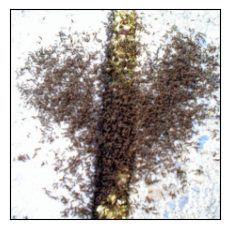

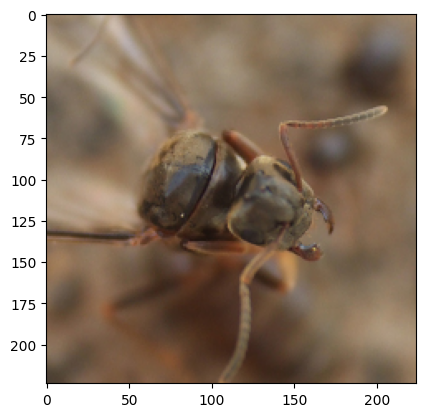

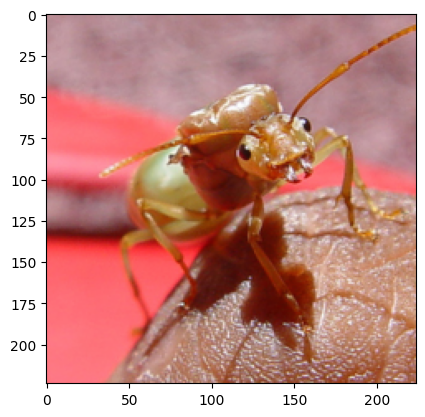

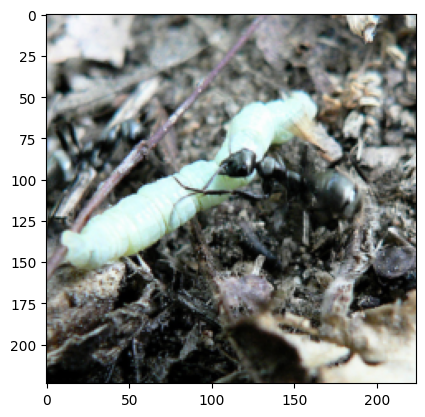

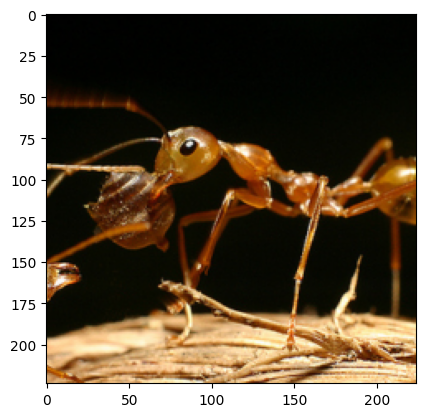

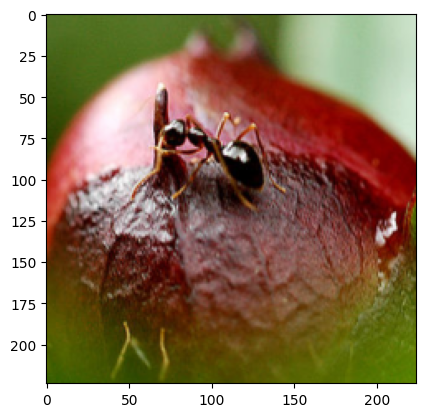

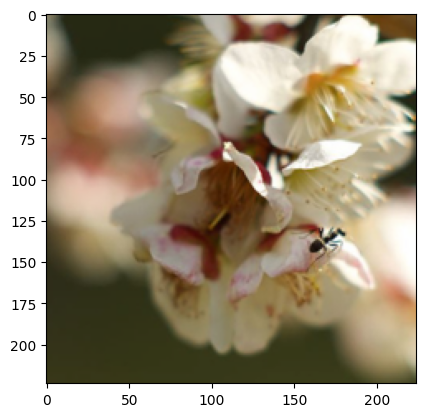

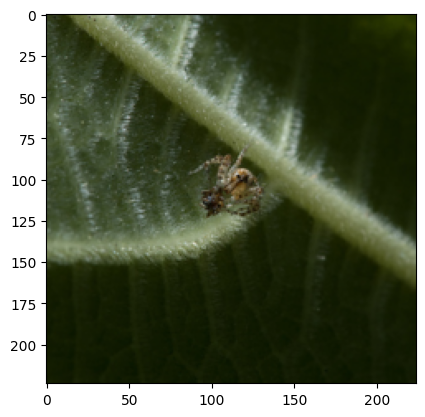

<Figure size 640x480 with 0 Axes>

In [43]:
import numpy as np

# Get a batch of validation data
dataiter = iter(val_loader)
images, labels = next(dataiter)

# Move images and labels to the device
images = images.to(device)
labels = labels.to(device)

# Make predictions
with torch.no_grad():
    tl_model.eval() # Set model to evaluation mode
    outputs = tl_model(images)
    _, predicted = torch.max(outputs, 1)

# Get class names from the dataset
class_names = train_dataset.classes

# Function to unnormalize and show an image
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Plot the first few images with predictions and true labels
num_images_to_show = 8
fig = plt.figure(figsize=(15, 6))
for i in range(num_images_to_show):
    ax = fig.add_subplot(2, num_images_to_show // 2, i + 1, xticks=[], yticks=[])
    imshow(images.cpu()[i])
    ax.set_title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted[i]]}",
                 color="green" if predicted[i] == labels[i] else "red")
plt.tight_layout()
plt.show()

## 6. Evaluate the Model (Quantitative)

In [44]:
correct = 0
total = 0

with torch.no_grad():
    tl_model.eval() # Set model to evaluation mode
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = tl_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model on the {len(val_dataset)} validation images: {100 * correct / total:.2f}%')

Accuracy of the model on the 153 validation images: 94.12%


### The adaptation workflow (the recipe)
1. Pick a pretrained model.
2. Freeze its layers.
3. Replace the final classifier to match **your** number of classes.
4. Prepare your images with the model's transforms.
5. Train only the new head on your dataset.
6. Evaluate.

## 7. A peek beyond classification

Pretrained models exist for more than "what is this?":

- **Object detection** — find *and locate* multiple objects with boxes (e.g. Faster R-CNN, **YOLO**). You'll see a live demo in the lab.
- **Segmentation** — label every pixel (which pixels are road, car, person).

The same idea holds everywhere: **start from a pretrained model, adapt it to your task.**

> This sets up your next sessions: **YOLO for object detection** builds directly on today's "use a pretrained model, then adapt it" mindset.

## ✅ Recap

- **Pretrained models** save you millions of images and days of training by reusing learned features.
- Load in one line; the `weights` object also gives you the **transforms** and **class names**.
- Inference = **preprocess → logits → softmax → top-k**.
- Pick a model by the **accuracy/speed** trade-off (ResNet is a safe default).
- **Preprocessing must match** what the model was trained on — the #1 bug.
- **Transfer learning:** freeze the backbone, replace the head, train only that — high accuracy from little data.

**Next (Lab):** classify real images with a pretrained ResNet, fix a broken preprocessing pipeline, run **transfer learning** on ants-vs-bees, and finish with a live **object detection** demo. Open `CV_Session2_Lab.ipynb`.